In [46]:
import numpy as np
import os
from scipy.stats import linregress
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.crs import EqualEarth, PlateCarree  
import matplotlib.gridspec as gridspec
import xeofs as xe
import xarray as xr
import h5py
from scipy import signal

This notebook is in part modeled after this EOF analysis of sea surface temperature data: https://podaac.github.io/tutorials/notebooks/DataStories/eof_example_ersst.html.

#### 1) Load in the monthly values of $\Delta C^*$ vertically integrated over the top $1500$ m (in mmol/m$^2$/month) for all years (1995-2022).

In [14]:
data_file = "../processed_data/monthly_dCstar_top1500m.h5"
# Create the data array with months over 1995-2022 time period
months = xr.date_range(start='1995-01-01', periods=384-48, freq='MS')

# load lat, lon, and dCstar arrays
with h5py.File(data_file, 'r') as f:
    lat = f['latitude'][:] 
    lon = f['longitude'][:] 
    dCstar = f['dCstar'][:]

print('Shape of array (lat, lon, months)', dCstar.shape)

Shape of array (lat, lon, months) (180, 360, 336)


In [16]:
# Conversion to x-array with dimension names and coordinates
# You can provide a dictionary for the 'coords' argument, mapping dimension names to their corresponding coordinate values

dcint_xr = xr.Dataset(
    {
        "dCstar": (("lat", "lon", "time"), dCstar),
    },
    coords={"lat": lat, "lon": lon, "time":  months},
)

print(dcint_xr)

<xarray.Dataset> Size: 174MB
Dimensions:  (lat: 180, lon: 360, time: 336)
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * time     (time) datetime64[ns] 3kB 1995-01-01 1995-02-01 ... 2022-12-01
Data variables:
    dCstar   (lat, lon, time) float64 174MB 0.0 0.0 0.0 ... 0.39 0.07024 0.2646


In [18]:
# Detrend: subtract the long-term linear trend
dcint = dcint_xr['dCstar'].load() #Load the variable into a DataArry object containing a NumPy array
p = dcint.polyfit(dim='time', deg=1) # Degree 1 polynomial fit coefficients over time for each lat, lon.
fit = xr.polyval(dcint['time'], p.polyfit_coefficients) # Compute linear trend time series at each lat, lon.
dcint_detrend = (dcint - fit) # xarray is smart enough to subtract along the time dim only.

# Remove a daily/monthly/yearly/etc cycle using Xarray built-in function:
seasonal_cycle = dcint_detrend.groupby("time.month").mean("time")
dcint_nocycle = dcint_detrend.groupby("time.month") - seasonal_cycle
dcint_anom_rolling = dcint_nocycle.rolling(time=12, center=True).mean()

#### 2) Calculate the EOFs and PC timeseries using xeofs

In [20]:
model = xe.single.EOF(
    n_modes=6, # first 6 modes
    use_coslat=True, # apply weight based on latitudinal differences in grid cell sizes
    standardize=False # don't standardize because want to capture magnitude of the signal
    )
model.fit(dcint_anom_rolling, dim='time')  # apply PCA in time

In [22]:
# EOFs ("components"):
components = model.components()

# PC's ("scores"):
# The package automatically normalizes the returned PC's. We back out the raw PC's as well (following https://github.com/nicrie/xeofs/issues/81):
scores_normed = model.scores()
svals = model.singular_values()
scores = scores_normed * svals

print('Shape of the EOF components (num_modes, lat, lon): ', components.shape)
print('Shape of the PC timeseries scores (num_modes, time): ', scores.shape)

Shape of the EOF components (num_modes, lat, lon):  (6, 180, 360)
Shape of the PC timeseries scores (num_modes, time):  (6, 336)


In [28]:
components = -components

In [24]:
# Calculate the percentage of variance explained by each mode
expvar = model.explained_variance_ratio()
print("Percentage of variance explained: ", expvar.values)
print("Cumulative percentage of variance explained: ",np.cumsum(expvar.values))

Percentage of variance explained:  [0.13061706 0.08069985 0.06226316 0.04639201 0.03907664 0.03458873]
Cumulative percentage of variance explained:  [0.13061706 0.21131691 0.27358007 0.31997209 0.35904873 0.39363746]


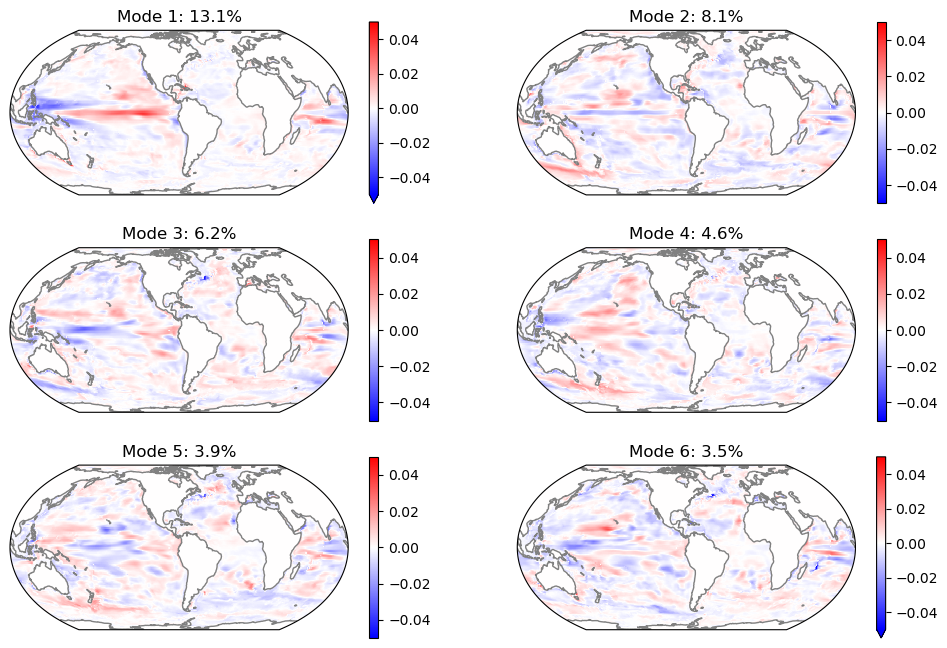

In [30]:
## Plot the top 6 EOFs

fig4 = plt.figure(figsize=(12, 8))
axes4 = []
proj = EqualEarth(central_longitude=-80)
for i in range(1, 7):
    axes4.append(plt.subplot(3, 2, i, projection=proj))


for ax in axes4:
    ax.coastlines(color='.5')


for i, ax in zip(range(1,7), axes4):
    components.sel(mode=i).plot(
        ax=ax, vmin=-0.05, vmax=0.05, 
        add_labels=False,
        transform=PlateCarree(), 
        cmap='bwr'
        
        )
    ax.set_title("Mode "+str(i)+": "+str(round(expvar.values[i-1]*100, 1))+"%", fontsize=12)

Save data as HDF5 file

In [34]:
with h5py.File('../processed_data/monthly_eof_6modes.h5', 'w') as f:
    dset = f.create_dataset('EOF components', data=components)
    f.create_dataset('PC timeseries', data=scores)
    f.create_dataset('latitude', data=lat)
    f.create_dataset('longitude', data=lon)

#### 3) Compute lag correlation with six climate mode variability indices

In [40]:
# Load pre-processed monthly data for climate indices
clim_index = np.load('../processed_data/climate_indices.npz')
enso = clim_index["enso"] # MEI index for ENSO
emi = clim_index["emi"] # EMI index for El Nino Modoki
atl3 = clim_index["atl3"] # ATL3 index for Atlantic Nino
npgo = clim_index["npgo"] # MEI index for ENSO
amo = clim_index["amo"] # EMI index for El Nino Modoki
pdo = clim_index["pdo"] # ATL3 index for Atlantic Nino

In [62]:
# Calculate the correlation for the first mode PC
pc = (scores[0] - np.mean(scores[0]))/np.std(scores[0])
corr_enso = signal.correlate(pc[6:-6], enso[6:-6])[323:]
lags_enso = signal.correlation_lags(len(pc[6:-6]), len(enso[6:-6]))[323:]
corr_emi = signal.correlate(pc[6:-6], emi[6:-6])[323:]
lags_emi = signal.correlation_lags(len(pc[6:-6]), len(emi[6:-6]))[323:]
corr_atl3 = signal.correlate(pc[6:-6], atl3[6:-6])[323:]
lags_atl3 = signal.correlation_lags(len(pc[6:-6]), len(atl3[6:-6]))[323:]
corr_npgo = signal.correlate(pc[6:-6], npgo[6:-6])[323:]
lags_npgo = signal.correlation_lags(len(pc[6:-6]), len(npgo[6:-6]))[323:]
corr_pdo = signal.correlate(pc[6:-6], pdo[6:-6])[323:]
lags_pdo = signal.correlation_lags(len(pc[6:-6]), len(pdo[6:-6]))[323:]
corr_amo = signal.correlate(pc[6:-6], amo[6:-6])[323:]
lags_amo = signal.correlation_lags(len(pc[6:-6]), len(amo[6:-6]))[323:]

# Save the maximum correlation (based on absolute value) for positive lag
corr1 = [corr_enso[np.argmax(abs(corr_enso))],
        corr_emi[np.argmax(abs(corr_emi))],
        corr_atl3[np.argmax(abs(corr_atl3))],
        corr_npgo[np.argmax(abs(corr_npgo))],
        corr_pdo[np.argmax(abs(corr_pdo))],
        corr_amo[np.argmax(abs(corr_amo))]]

# Print results only considering positive lag

print('ENSO: ', 'max abs correlation ', np.round(np.max(abs(corr_enso))), 
      ', lag (years) ', np.round(lags_enso[np.argmax(abs(corr_enso))]/12., 2), 
      ', corr including sign ', np.round(corr_enso[np.argmax(abs(corr_enso))]))
print('EMI:  ', 'max abs correlation ', np.round(np.max(abs(corr_emi))), 
      ', lag (years) ', np.round(lags_emi[np.argmax(abs(corr_emi))]/12., 2), 
      ', corr including sign ', np.round(corr_emi[np.argmax(abs(corr_emi))]))
print('ATL3: ', 'max abs correlation ', np.round(np.max(abs(corr_atl3))), 
      ', lag (years) ', np.round(lags_atl3[np.argmax(abs(corr_atl3))]/12., 2),
      ', corr including sign ', np.round(corr_atl3[np.argmax(abs(corr_atl3))]))
print('NPGO: ', 'max abs correlation ', np.round(np.max(abs(corr_npgo))), 
      ', lag (years) ', np.round(lags_npgo[np.argmax(abs(corr_npgo))]/12., 2), 
      ', corr including sign ', np.round(corr_npgo[np.argmax(abs(corr_npgo))]))
print('PDO:  ', 'max abs correlation ', np.round(np.max(abs(corr_pdo))), 
      ', lag (years) ', np.round(lags_pdo[np.argmax(abs(corr_pdo))]/12., 2), 
      ', corr including sign ', np.round(corr_pdo[np.argmax(abs(corr_pdo))]))
print('AMO:  ', 'max abs correlation ', np.round(np.max(abs(corr_amo))), 
      ', lag (years) ', np.round(lags_amo[np.argmax(abs(corr_amo))]/12., 2), 
      ', corr including sign ', np.round(corr_amo[np.argmax(abs(corr_amo))]))

ENSO:  max abs correlation  164.0 , lag (years)  0.75 , corr including sign  164.0
EMI:   max abs correlation  51.0 , lag (years)  1.33 , corr including sign  -51.0
ATL3:  max abs correlation  54.0 , lag (years)  0.0 , corr including sign  -54.0
NPGO:  max abs correlation  125.0 , lag (years)  1.42 , corr including sign  125.0
PDO:   max abs correlation  128.0 , lag (years)  0.83 , corr including sign  -128.0
AMO:   max abs correlation  24.0 , lag (years)  1.17 , corr including sign  -24.0


In [64]:
# Calculate the correlation for the second mode PC
pc = (scores[1] - np.mean(scores[1]))/np.std(scores[1])
corr_enso = signal.correlate(pc[6:-6], enso[6:-6])[323:]
lags_enso = signal.correlation_lags(len(pc[6:-6]), len(enso[6:-6]))[323:]
corr_emi = signal.correlate(pc[6:-6], emi[6:-6])[323:]
lags_emi = signal.correlation_lags(len(pc[6:-6]), len(emi[6:-6]))[323:]
corr_atl3 = signal.correlate(pc[6:-6], atl3[6:-6])[323:]
lags_atl3 = signal.correlation_lags(len(pc[6:-6]), len(atl3[6:-6]))[323:]
corr_npgo = signal.correlate(pc[6:-6], npgo[6:-6])[323:]
lags_npgo = signal.correlation_lags(len(pc[6:-6]), len(npgo[6:-6]))[323:]
corr_pdo = signal.correlate(pc[6:-6], pdo[6:-6])[323:]
lags_pdo = signal.correlation_lags(len(pc[6:-6]), len(pdo[6:-6]))[323:]
corr_amo = signal.correlate(pc[6:-6], amo[6:-6])[323:]
lags_amo = signal.correlation_lags(len(pc[6:-6]), len(amo[6:-6]))[323:]

# Save the maximum correlation (based on absolute value) for positive lag
corr2 = [corr_enso[np.argmax(abs(corr_enso))],
        corr_emi[np.argmax(abs(corr_emi))],
        corr_atl3[np.argmax(abs(corr_atl3))],
        corr_npgo[np.argmax(abs(corr_npgo))],
        corr_pdo[np.argmax(abs(corr_pdo))],
        corr_amo[np.argmax(abs(corr_amo))]]

# Print results only considering positive lag

print('ENSO: ', 'max abs correlation ', np.round(np.max(abs(corr_enso))), 
      ', lag (years) ', np.round(lags_enso[np.argmax(abs(corr_enso))]/12., 2), 
      ', corr including sign ', np.round(corr_enso[np.argmax(abs(corr_enso))]))
print('EMI:  ', 'max abs correlation ', np.round(np.max(abs(corr_emi))), 
      ', lag (years) ', np.round(lags_emi[np.argmax(abs(corr_emi))]/12., 2), 
      ', corr including sign ', np.round(corr_emi[np.argmax(abs(corr_emi))]))
print('ATL3: ', 'max abs correlation ', np.round(np.max(abs(corr_atl3))), 
      ', lag (years) ', np.round(lags_atl3[np.argmax(abs(corr_atl3))]/12., 2),
      ', corr including sign ', np.round(corr_atl3[np.argmax(abs(corr_atl3))]))
print('NPGO: ', 'max abs correlation ', np.round(np.max(abs(corr_npgo))), 
      ', lag (years) ', np.round(lags_npgo[np.argmax(abs(corr_npgo))]/12., 2), 
      ', corr including sign ', np.round(corr_npgo[np.argmax(abs(corr_npgo))]))
print('PDO:  ', 'max abs correlation ', np.round(np.max(abs(corr_pdo))), 
      ', lag (years) ', np.round(lags_pdo[np.argmax(abs(corr_pdo))]/12., 2), 
      ', corr including sign ', np.round(corr_pdo[np.argmax(abs(corr_pdo))]))
print('AMO:  ', 'max abs correlation ', np.round(np.max(abs(corr_amo))), 
      ', lag (years) ', np.round(lags_amo[np.argmax(abs(corr_amo))]/12., 2), 
      ', corr including sign ', np.round(corr_amo[np.argmax(abs(corr_amo))]))

ENSO:  max abs correlation  129.0 , lag (years)  0.33 , corr including sign  -129.0
EMI:   max abs correlation  43.0 , lag (years)  2.0 , corr including sign  -43.0
ATL3:  max abs correlation  45.0 , lag (years)  0.92 , corr including sign  -45.0
NPGO:  max abs correlation  135.0 , lag (years)  0.0 , corr including sign  135.0
PDO:   max abs correlation  82.0 , lag (years)  1.42 , corr including sign  -82.0
AMO:   max abs correlation  17.0 , lag (years)  0.58 , corr including sign  17.0


In [66]:
# Calculate the correlation for the third mode PC
pc = (scores[2] - np.mean(scores[2]))/np.std(scores[2])
corr_enso = signal.correlate(pc[6:-6], enso[6:-6])[323:]
lags_enso = signal.correlation_lags(len(pc[6:-6]), len(enso[6:-6]))[323:]
corr_emi = signal.correlate(pc[6:-6], emi[6:-6])[323:]
lags_emi = signal.correlation_lags(len(pc[6:-6]), len(emi[6:-6]))[323:]
corr_atl3 = signal.correlate(pc[6:-6], atl3[6:-6])[323:]
lags_atl3 = signal.correlation_lags(len(pc[6:-6]), len(atl3[6:-6]))[323:]
corr_npgo = signal.correlate(pc[6:-6], npgo[6:-6])[323:]
lags_npgo = signal.correlation_lags(len(pc[6:-6]), len(npgo[6:-6]))[323:]
corr_pdo = signal.correlate(pc[6:-6], pdo[6:-6])[323:]
lags_pdo = signal.correlation_lags(len(pc[6:-6]), len(pdo[6:-6]))[323:]
corr_amo = signal.correlate(pc[6:-6], amo[6:-6])[323:]
lags_amo = signal.correlation_lags(len(pc[6:-6]), len(amo[6:-6]))[323:]

# Save the maximum correlation (based on absolute value) for positive lag
corr3 = [corr_enso[np.argmax(abs(corr_enso))],
        corr_emi[np.argmax(abs(corr_emi))],
        corr_atl3[np.argmax(abs(corr_atl3))],
        corr_npgo[np.argmax(abs(corr_npgo))],
        corr_pdo[np.argmax(abs(corr_pdo))],
        corr_amo[np.argmax(abs(corr_amo))]]

# Print results only considering positive lag

print('ENSO: ', 'max abs correlation ', np.round(np.max(abs(corr_enso))), 
      ', lag (years) ', np.round(lags_enso[np.argmax(abs(corr_enso))]/12., 2), 
      ', corr including sign ', np.round(corr_enso[np.argmax(abs(corr_enso))]))
print('EMI:  ', 'max abs correlation ', np.round(np.max(abs(corr_emi))), 
      ', lag (years) ', np.round(lags_emi[np.argmax(abs(corr_emi))]/12., 2), 
      ', corr including sign ', np.round(corr_emi[np.argmax(abs(corr_emi))]))
print('ATL3: ', 'max abs correlation ', np.round(np.max(abs(corr_atl3))), 
      ', lag (years) ', np.round(lags_atl3[np.argmax(abs(corr_atl3))]/12., 2),
      ', corr including sign ', np.round(corr_atl3[np.argmax(abs(corr_atl3))]))
print('NPGO: ', 'max abs correlation ', np.round(np.max(abs(corr_npgo))), 
      ', lag (years) ', np.round(lags_npgo[np.argmax(abs(corr_npgo))]/12., 2), 
      ', corr including sign ', np.round(corr_npgo[np.argmax(abs(corr_npgo))]))
print('PDO:  ', 'max abs correlation ', np.round(np.max(abs(corr_pdo))), 
      ', lag (years) ', np.round(lags_pdo[np.argmax(abs(corr_pdo))]/12., 2), 
      ', corr including sign ', np.round(corr_pdo[np.argmax(abs(corr_pdo))]))
print('AMO:  ', 'max abs correlation ', np.round(np.max(abs(corr_amo))), 
      ', lag (years) ', np.round(lags_amo[np.argmax(abs(corr_amo))]/12., 2), 
      ', corr including sign ', np.round(corr_amo[np.argmax(abs(corr_amo))]))

ENSO:  max abs correlation  143.0 , lag (years)  0.17 , corr including sign  -143.0
EMI:   max abs correlation  81.0 , lag (years)  0.33 , corr including sign  81.0
ATL3:  max abs correlation  32.0 , lag (years)  0.67 , corr including sign  -32.0
NPGO:  max abs correlation  151.0 , lag (years)  0.0 , corr including sign  -151.0
PDO:   max abs correlation  184.0 , lag (years)  0.0 , corr including sign  184.0
AMO:   max abs correlation  25.0 , lag (years)  1.75 , corr including sign  -25.0


In [68]:
# Calculate the correlation for the fourth mode PC
pc = (scores[3] - np.mean(scores[3]))/np.std(scores[3])
corr_enso = signal.correlate(pc[6:-6], enso[6:-6])[323:]
lags_enso = signal.correlation_lags(len(pc[6:-6]), len(enso[6:-6]))[323:]
corr_emi = signal.correlate(pc[6:-6], emi[6:-6])[323:]
lags_emi = signal.correlation_lags(len(pc[6:-6]), len(emi[6:-6]))[323:]
corr_atl3 = signal.correlate(pc[6:-6], atl3[6:-6])[323:]
lags_atl3 = signal.correlation_lags(len(pc[6:-6]), len(atl3[6:-6]))[323:]
corr_npgo = signal.correlate(pc[6:-6], npgo[6:-6])[323:]
lags_npgo = signal.correlation_lags(len(pc[6:-6]), len(npgo[6:-6]))[323:]
corr_pdo = signal.correlate(pc[6:-6], pdo[6:-6])[323:]
lags_pdo = signal.correlation_lags(len(pc[6:-6]), len(pdo[6:-6]))[323:]
corr_amo = signal.correlate(pc[6:-6], amo[6:-6])[323:]
lags_amo = signal.correlation_lags(len(pc[6:-6]), len(amo[6:-6]))[323:]

# Save the maximum correlation (based on absolute value) for positive lag
corr4 = [corr_enso[np.argmax(abs(corr_enso))],
        corr_emi[np.argmax(abs(corr_emi))],
        corr_atl3[np.argmax(abs(corr_atl3))],
        corr_npgo[np.argmax(abs(corr_npgo))],
        corr_pdo[np.argmax(abs(corr_pdo))],
        corr_amo[np.argmax(abs(corr_amo))]]

# Print results only considering positive lag

print('ENSO: ', 'max abs correlation ', np.round(np.max(abs(corr_enso))), 
      ', lag (years) ', np.round(lags_enso[np.argmax(abs(corr_enso))]/12., 2), 
      ', corr including sign ', np.round(corr_enso[np.argmax(abs(corr_enso))]))
print('EMI:  ', 'max abs correlation ', np.round(np.max(abs(corr_emi))), 
      ', lag (years) ', np.round(lags_emi[np.argmax(abs(corr_emi))]/12., 2), 
      ', corr including sign ', np.round(corr_emi[np.argmax(abs(corr_emi))]))
print('ATL3: ', 'max abs correlation ', np.round(np.max(abs(corr_atl3))), 
      ', lag (years) ', np.round(lags_atl3[np.argmax(abs(corr_atl3))]/12., 2),
      ', corr including sign ', np.round(corr_atl3[np.argmax(abs(corr_atl3))]))
print('NPGO: ', 'max abs correlation ', np.round(np.max(abs(corr_npgo))), 
      ', lag (years) ', np.round(lags_npgo[np.argmax(abs(corr_npgo))]/12., 2), 
      ', corr including sign ', np.round(corr_npgo[np.argmax(abs(corr_npgo))]))
print('PDO:  ', 'max abs correlation ', np.round(np.max(abs(corr_pdo))), 
      ', lag (years) ', np.round(lags_pdo[np.argmax(abs(corr_pdo))]/12., 2), 
      ', corr including sign ', np.round(corr_pdo[np.argmax(abs(corr_pdo))]))
print('AMO:  ', 'max abs correlation ', np.round(np.max(abs(corr_amo))), 
      ', lag (years) ', np.round(lags_amo[np.argmax(abs(corr_amo))]/12., 2), 
      ', corr including sign ', np.round(corr_amo[np.argmax(abs(corr_amo))]))

ENSO:  max abs correlation  64.0 , lag (years)  2.0 , corr including sign  64.0
EMI:   max abs correlation  58.0 , lag (years)  0.0 , corr including sign  58.0
ATL3:  max abs correlation  20.0 , lag (years)  1.58 , corr including sign  -20.0
NPGO:  max abs correlation  168.0 , lag (years)  1.5 , corr including sign  168.0
PDO:   max abs correlation  146.0 , lag (years)  2.0 , corr including sign  -146.0
AMO:   max abs correlation  14.0 , lag (years)  4.0 , corr including sign  14.0


#### 4) Reproduce manuscript figure

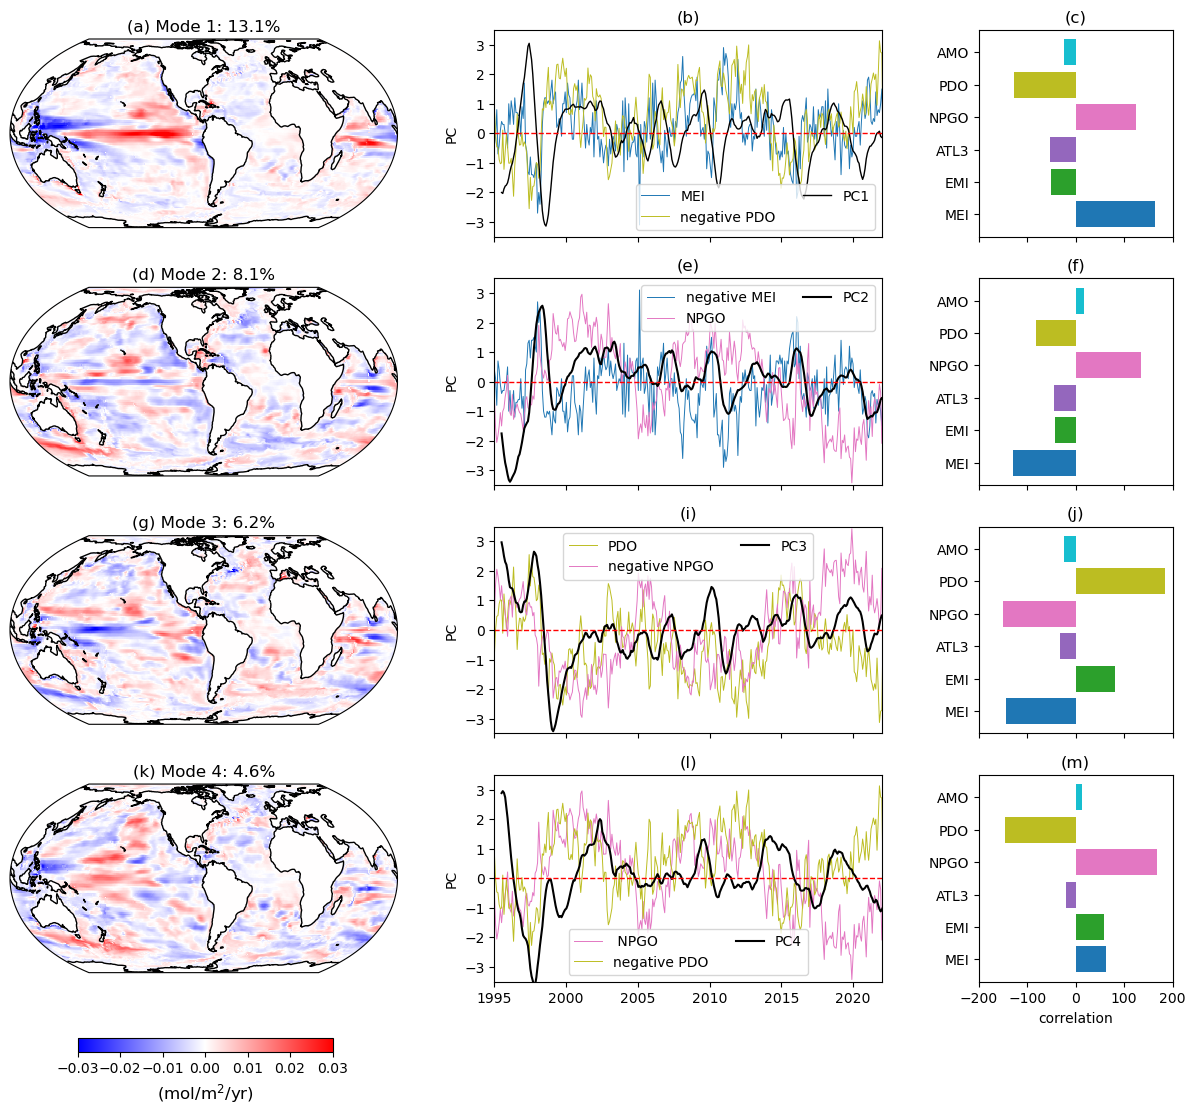

In [76]:
indices = ['MEI', 'EMI', 'ATL3', 'NPGO', 'PDO', 'AMO']
y = np.arange(1,7,1)
my_cmap = plt.get_cmap("tab10")
rescale = lambda y: (y - np.min(y)) / (np.max(y) - np.min(y))
color2=my_cmap(rescale(y))
color = color2#[1:-2]

fig = plt.figure(figsize=(15, 14))
gs = gridspec.GridSpec(nrows=4, ncols=3, width_ratios=[2, 2, 1])
titles = ["(a) ", "(d) ", "(g) ", "(k) "]

proj = EqualEarth(central_longitude=-80)
for i in range(1, 5):
    ax = fig.add_subplot(gs[i-1, 0], projection=proj)
    ax.coastlines()
    im = ax.pcolormesh(lon, lat, components[i-1, :, :], 
         cmap='bwr', vmin=-0.03, vmax=0.03, transform=ccrs.PlateCarree())
    ax.set_title( titles[i-1]+ "Mode "+str(i)+": "+str(round(expvar.values[i-1]*100, 1))+"%", fontsize=12)

ax = fig.add_subplot(gs[0, 1])
pc1 = (scores[0] - np.mean(scores[0]))/np.std(scores[0])
ax.plot(np.linspace(1995, 2023, len(enso)),enso, color=color[0], linewidth=0.7, label='MEI')
ax.plot(np.linspace(1995, 2023, len(npgo)),-pdo, color=color[4], linewidth=0.7, label='negative PDO')
ax.plot(np.linspace(1995, 2023, len(pc1)), pc1, '-k', linewidth=1,  label='PC1')
ax.legend(ncol=2)
ax.plot(np.linspace(1995, 2023, len(enso)),np.zeros((len(enso),)), '--r', linewidth=1)
ax.set_xlim([1995, 2022])
ax.set_xticklabels([])
ax.set_ylim([-3.5, 3.5])
ax.set(ylabel='PC', title="(b)")

ax = fig.add_subplot(gs[1, 1])
pc2 = (scores[1] - np.mean(scores[1]))/np.std(scores[1])
ax.plot(np.linspace(1995, 2023, len(enso)),-enso, color=color[0], linewidth=0.7, label='negative MEI')
ax.plot(np.linspace(1995, 2023, len(enso)),npgo, color=color[3], linewidth=0.7, label='NPGO')
ax.plot(np.linspace(1995, 2023, len(pc1)), pc2, '-k', linewidth=1.5,  label='PC2')
ax.legend(ncol=2)
ax.plot(np.linspace(1995, 2023, len(enso)),np.zeros((len(enso),)), '--r', linewidth=1)
ax.set_xlim([1995, 2022])
ax.set_xticklabels([])
ax.set_ylim([-3.5, 3.5])
ax.set(ylabel='PC', title="(e)")

ax = fig.add_subplot(gs[2, 1])
pc3 = (scores[2] - np.mean(scores[2]))/np.std(scores[2])
ax.plot(np.linspace(1995, 2023, len(pdo)),pdo, color=color[4], linewidth=0.7, label='PDO')
ax.plot(np.linspace(1995, 2023, len(npgo)),-npgo, color=color[3], linewidth=0.7, label='negative NPGO')
ax.plot(np.linspace(1995, 2023, len(pc1)), pc3, '-k', linewidth=1.5, label='PC3')
ax.legend(ncol=2)
ax.plot(np.linspace(1995, 2023, len(npgo)),np.zeros((len(npgo),)), '--r', linewidth=1)
ax.set_xlim([1995, 2022])
ax.set_xticklabels([])
ax.set_ylim([-3.5, 3.5])
ax.set(ylabel='PC', title="(i)")

ax = fig.add_subplot(gs[3, 1])
pc4 = (scores[3] - np.mean(scores[3]))/np.std(scores[3])
ax.plot(np.linspace(1995, 2023, len(npgo)),npgo, color=color[3], linewidth=0.7, label=' NPGO')
ax.plot(np.linspace(1995, 2023, len(pdo)),-pdo, color=color[4], linewidth=0.7, label='negative PDO')
ax.plot(np.linspace(1995, 2023, len(pc1)), pc4, '-k', linewidth=1.5, label='PC4')
ax.legend(ncol=2)
ax.plot(np.linspace(1995, 2023, len(npgo)),np.zeros((len(npgo),)), '--r', linewidth=1)
ax.set_xlim([1995, 2022])
ax.set_ylim([-3.5, 3.5])
ax.set(ylabel='PC', title="(l)")


ax = fig.add_subplot(gs[0, 2])
ax.barh(indices, corr1, color=color)
ax.set_xticklabels([])
ax.set_xlim([-200, 200])
ax.set(title="(c)")

ax = fig.add_subplot(gs[1, 2])
ax.barh(indices, corr2, color=color)
ax.set_xticklabels([])
ax.set_xlim([-200, 200])
ax.set(title="(f)")

ax = fig.add_subplot(gs[2, 2])
ax.barh(indices, corr3, color=color)
ax.set_xticklabels([])
ax.set_xlim([-200, 200])
ax.set(title="(j)")

ax = fig.add_subplot(gs[3, 2])
ax.barh(indices, corr4, color=color)
ax.set_xlim([-200, 200])
ax.set(xlabel='correlation', title="(m)")

fig.subplots_adjust(bottom=0.2, wspace=0.3, hspace=0.2)
cbar_ax = fig.add_axes([0.17, 0.15, 0.17, 0.01])
cb = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", pad=0.2)
#cb.set_label(r'$\widehat{\Delta C^*}$ (mol/m$^2$/yr)', fontsize=12)
cb.set_label('(mol/m$^2$/yr)', fontsize=12)

fig.savefig("../figures/eof_analysis_monthly.png", dpi=600, bbox_inches='tight')